In [1]:
import os
import time
import copy
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
DATA_DIR = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

print("Dataset directory:", DATA_DIR)
print("Exists:", os.path.exists(DATA_DIR))

Dataset directory: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage
Exists: True


In [4]:
tomato_classes = [
    "Tomato_Leaf_Mold",
    "Tomato__Tomato_YellowLeaf__Curl_Virus",
    "Tomato_Bacterial_spot",
    "Tomato_Septoria_leaf_spot",
    "Tomato_healthy",
    "Tomato_Spider_mites_Two_spotted_spider_mite",
    "Tomato_Early_blight",
    "Tomato__Target_Spot",
    "Tomato_Late_blight",
    "Tomato__Tomato_mosaic_virus"
]

for cls in tomato_classes:
    cls_path = os.path.join(DATA_DIR, cls)
    print(cls, "->", os.path.exists(cls_path))

Tomato_Leaf_Mold -> True
Tomato__Tomato_YellowLeaf__Curl_Virus -> True
Tomato_Bacterial_spot -> True
Tomato_Septoria_leaf_spot -> True
Tomato_healthy -> True
Tomato_Spider_mites_Two_spotted_spider_mite -> True
Tomato_Early_blight -> True
Tomato__Target_Spot -> True
Tomato_Late_blight -> True
Tomato__Tomato_mosaic_virus -> True


In [5]:
image_paths = []
labels = []

for cls in tomato_classes:
    cls_path = os.path.join(DATA_DIR, cls)
    if not os.path.exists(cls_path):
        print(f"Warning: {cls_path} not found")
        continue
    
    for file_name in os.listdir(cls_path):
        file_path = os.path.join(cls_path, file_name)
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(file_path)
            labels.append(cls)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total images:", len(df))
df.head()

Total images: 16011


,image_path,label
0,/kaggle/input/datasets/emmarex/plantdisease/Pl...,Tomato_Leaf_Mold
1,/kaggle/input/datasets/emmarex/plantdisease/Pl...,Tomato_Leaf_Mold
2,/kaggle/input/datasets/emmarex/plantdisease/Pl...,Tomato_Leaf_Mold
3,/kaggle/input/datasets/emmarex/plantdisease/Pl...,Tomato_Leaf_Mold
4,/kaggle/input/datasets/emmarex/plantdisease/Pl...,Tomato_Leaf_Mold


In [6]:
class_to_idx = {cls: idx for idx, cls in enumerate(sorted(df["label"].unique()))}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

df["label_idx"] = df["label"].map(class_to_idx)

print("Number of classes:", len(class_to_idx))
print(class_to_idx)

Number of classes: 10
{'Tomato_Bacterial_spot': 0, 'Tomato_Early_blight': 1, 'Tomato_Late_blight': 2, 'Tomato_Leaf_Mold': 3, 'Tomato_Septoria_leaf_spot': 4, 'Tomato_Spider_mites_Two_spotted_spider_mite': 5, 'Tomato__Target_Spot': 6, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 7, 'Tomato__Tomato_mosaic_virus': 8, 'Tomato_healthy': 9}


label
Tomato_Bacterial_spot                          2127
Tomato_Early_blight                            1000
Tomato_Late_blight                             1909
Tomato_Leaf_Mold                                952
Tomato_Septoria_leaf_spot                      1771
Tomato_Spider_mites_Two_spotted_spider_mite    1676
Tomato__Target_Spot                            1404
Tomato__Tomato_YellowLeaf__Curl_Virus          3208
Tomato__Tomato_mosaic_virus                     373
Tomato_healthy                                 1591
Name: count, dtype: int64

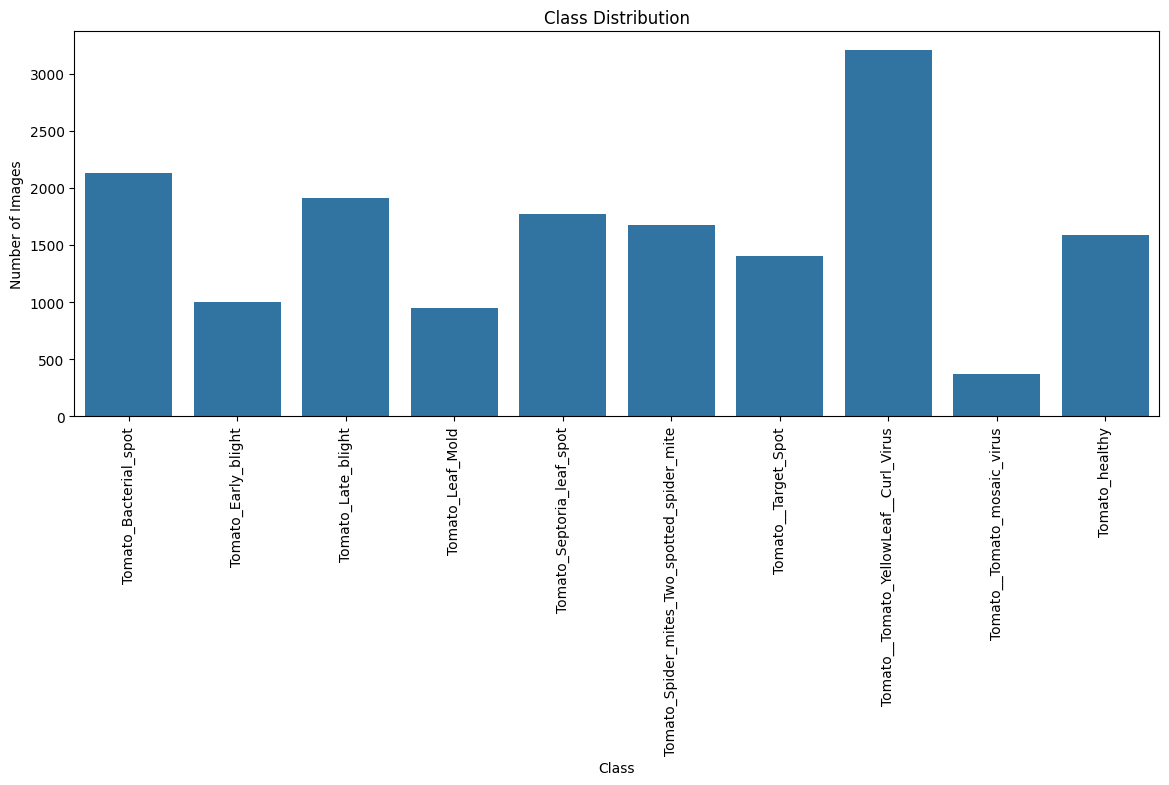

In [7]:
class_counts = df["label"].value_counts().sort_index()
display(class_counts)

plt.figure(figsize=(14,5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

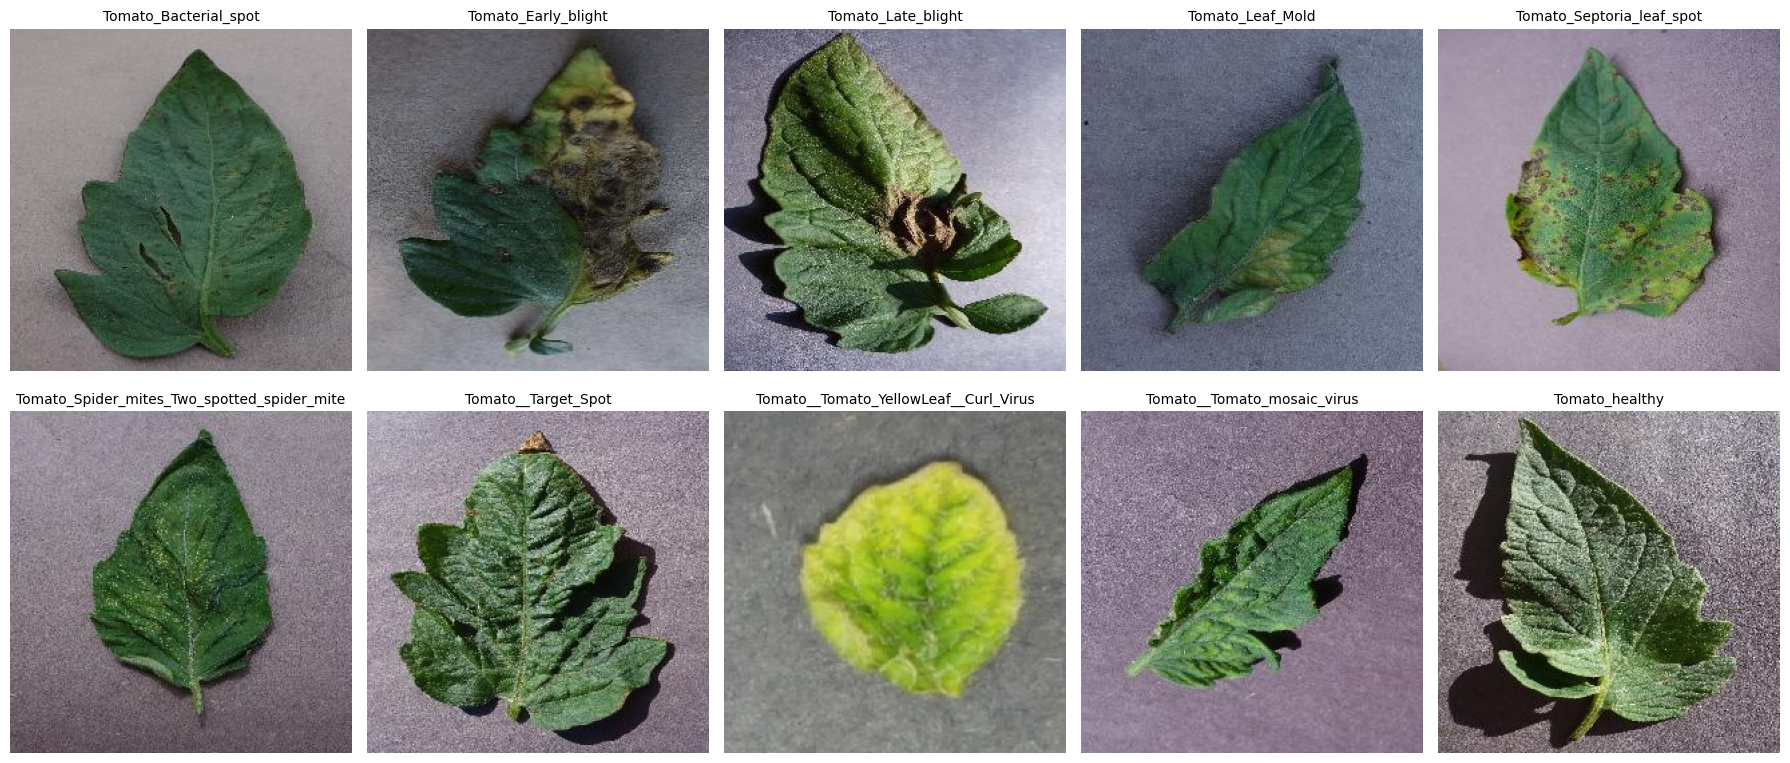

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, cls in enumerate(sorted(df["label"].unique())):
    sample_path = df[df["label"] == cls]["image_path"].iloc[0]
    img = Image.open(sample_path).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [9]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label_idx"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_idx"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain class distribution:")
display(train_df["label"].value_counts().sort_index())

print("\nValidation class distribution:")
display(val_df["label"].value_counts().sort_index())

print("\nTest class distribution:")
display(test_df["label"].value_counts().sort_index())

Train: 11207
Validation: 2402
Test: 2402

Train class distribution:


label
Tomato_Bacterial_spot                          1489
Tomato_Early_blight                             700
Tomato_Late_blight                             1336
Tomato_Leaf_Mold                                666
Tomato_Septoria_leaf_spot                      1240
Tomato_Spider_mites_Two_spotted_spider_mite    1173
Tomato__Target_Spot                             983
Tomato__Tomato_YellowLeaf__Curl_Virus          2245
Tomato__Tomato_mosaic_virus                     261
Tomato_healthy                                 1114
Name: count, dtype: int64


Validation class distribution:


label
Tomato_Bacterial_spot                          319
Tomato_Early_blight                            150
Tomato_Late_blight                             286
Tomato_Leaf_Mold                               143
Tomato_Septoria_leaf_spot                      266
Tomato_Spider_mites_Two_spotted_spider_mite    251
Tomato__Target_Spot                            211
Tomato__Tomato_YellowLeaf__Curl_Virus          481
Tomato__Tomato_mosaic_virus                     56
Tomato_healthy                                 239
Name: count, dtype: int64


Test class distribution:


label
Tomato_Bacterial_spot                          319
Tomato_Early_blight                            150
Tomato_Late_blight                             287
Tomato_Leaf_Mold                               143
Tomato_Septoria_leaf_spot                      265
Tomato_Spider_mites_Two_spotted_spider_mite    252
Tomato__Target_Spot                            210
Tomato__Tomato_YellowLeaf__Curl_Virus          482
Tomato__Tomato_mosaic_virus                     56
Tomato_healthy                                 238
Name: count, dtype: int64

In [10]:
IMG_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [11]:
class TomatoDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "image_path"]
        label = self.dataframe.loc[idx, "label_idx"]
        
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [12]:
BATCH_SIZE = 32

train_dataset = TomatoDataset(train_df, transform=train_transforms)
val_dataset = TomatoDataset(val_df, transform=val_test_transforms)
test_dataset = TomatoDataset(test_df, transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 351
Val batches: 76
Test batches: 76


In [13]:
train_class_counts = train_df["label_idx"].value_counts().sort_index().values
num_classes = len(class_to_idx)
total_samples = len(train_df)

class_weights = total_samples / (num_classes * train_class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Train class counts:", train_class_counts)
print("Class weights:", class_weights)

Train class counts: [1489  700 1336  666 1240 1173  983 2245  261 1114]
Class weights: tensor([0.7527, 1.6010, 0.8388, 1.6827, 0.9038, 0.9554, 1.1401, 0.4992, 4.2939,
        1.0060], device='cuda:0')


In [14]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // reduction, in_channels, kernel_size=1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(x_cat)
        return self.sigmoid(out)


class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)
    
    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)
        return x

In [15]:
class AttentionCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(AttentionCNN, self).__init__()
        
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        
        self.cbam3 = CBAM(128)
        self.cbam4 = CBAM(256)
        
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.cbam3(x)
        x = self.block4(x)
        x = self.cbam4(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

In [16]:
model = AttentionCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

print(model)

AttentionCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), str

In [17]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.early_stop = False
    
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [18]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [19]:
EPOCHS = 50
early_stopping = EarlyStopping(patience=5)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_loss = float("inf")

train_start_time = time.time()

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "best_attention_cnn_cbam.pth")
    
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

train_end_time = time.time()
training_time = train_end_time - train_start_time

print(f"\nTotal Training Time: {training_time:.2f} seconds")

Epoch [1/50] Train Loss: 1.6492 | Train Acc: 0.4873 | Val Loss: 0.9721 | Val Acc: 0.7348
Epoch [2/50] Train Loss: 0.8914 | Train Acc: 0.7199 | Val Loss: 0.5652 | Val Acc: 0.8405
Epoch [3/50] Train Loss: 0.6543 | Train Acc: 0.7917 | Val Loss: 0.4081 | Val Acc: 0.8809
Epoch [4/50] Train Loss: 0.5267 | Train Acc: 0.8296 | Val Loss: 0.3238 | Val Acc: 0.9055
Epoch [5/50] Train Loss: 0.4439 | Train Acc: 0.8557 | Val Loss: 0.3007 | Val Acc: 0.8972
Epoch [6/50] Train Loss: 0.3845 | Train Acc: 0.8746 | Val Loss: 0.2411 | Val Acc: 0.9242
Epoch [7/50] Train Loss: 0.3350 | Train Acc: 0.8921 | Val Loss: 0.2393 | Val Acc: 0.9130
Epoch [8/50] Train Loss: 0.2913 | Train Acc: 0.9070 | Val Loss: 0.1808 | Val Acc: 0.9446
Epoch [9/50] Train Loss: 0.2736 | Train Acc: 0.9141 | Val Loss: 0.1628 | Val Acc: 0.9488
Epoch [10/50] Train Loss: 0.2419 | Train Acc: 0.9232 | Val Loss: 0.1912 | Val Acc: 0.9292
Epoch [11/50] Train Loss: 0.2267 | Train Acc: 0.9281 | Val Loss: 0.1911 | Val Acc: 0.9367
Epoch [12/50] Train

In [20]:
model.load_state_dict(best_model_wts)
print("Best model loaded.")

Best model loaded.


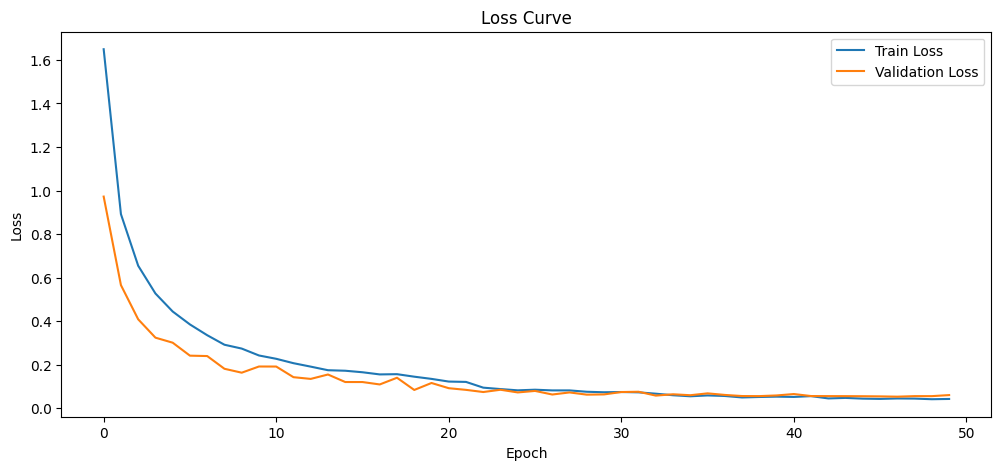

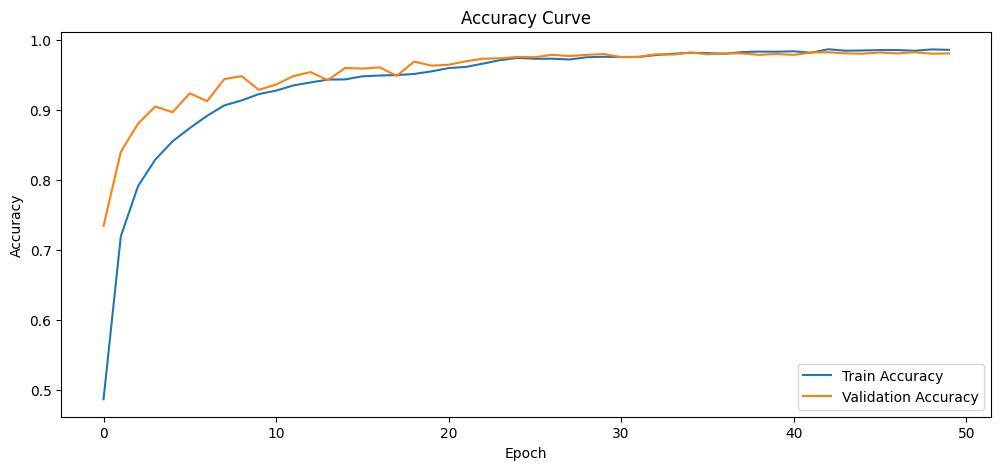

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [22]:
def evaluate_model(model, loader, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    test_start_time = time.time()
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    
    test_end_time = time.time()
    testing_time = test_end_time - test_start_time
    
    return np.array(all_labels), np.array(all_preds), np.array(all_probs), testing_time

In [23]:
y_true, y_pred, y_prob, testing_time = evaluate_model(model, test_loader, device)

print("Testing Time:", round(testing_time, 2), "seconds")
print("Done.")

Testing Time: 15.58 seconds
Done.


In [24]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1-score       : {f1:.4f}")
print(f"Training Time  : {training_time:.2f} sec")
print(f"Testing Time   : {testing_time:.2f} sec")

Accuracy       : 0.9896
Precision      : 0.9870
Recall         : 0.9900
F1-score       : 0.9885
Training Time  : 2265.76 sec
Testing Time   : 15.58 sec


In [25]:
report = classification_report(
    y_true,
    y_pred,
    target_names=[idx_to_class[i] for i in range(num_classes)],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
display(report_df)

,precision,recall,f1-score,support
Tomato_Bacterial_spot,0.996835,0.987461,0.992126,319.000000
Tomato_Early_blight,0.954248,0.973333,0.963696,150.000000
Tomato_Late_blight,0.996429,0.972125,0.984127,287.000000
Tomato_Leaf_Mold,1.000000,1.000000,1.000000,143.000000
Tomato_Septoria_leaf_spot,0.985075,0.996226,0.990619,265.000000
Tomato_Spider_mites_Two_spotted_spider_mite,0.984314,0.996032,0.990138,252.000000
Tomato__Target_Spot,0.985646,0.980952,0.983294,210.000000
Tomato__Tomato_YellowLeaf__Curl_Virus,0.997917,0.993776,0.995842,482.000000
Tomato__Tomato_mosaic_virus,0.982456,1.000000,0.991150,56.000000
Tomato_healthy,0.987552,1.000000,0.993737,238.000000


In [26]:
cm = confusion_matrix(y_true, y_pred)

class_accuracy = cm.diagonal() / cm.sum(axis=1)

class_acc_df = pd.DataFrame({
    "Class": [idx_to_class[i] for i in range(num_classes)],
    "Class Accuracy": class_accuracy
})

display(class_acc_df)

,Class,Class Accuracy
0,Tomato_Bacterial_spot,0.987461
1,Tomato_Early_blight,0.973333
2,Tomato_Late_blight,0.972125
3,Tomato_Leaf_Mold,1.000000
4,Tomato_Septoria_leaf_spot,0.996226
5,Tomato_Spider_mites_Two_spotted_spider_mite,0.996032
6,Tomato__Target_Spot,0.980952
7,Tomato__Tomato_YellowLeaf__Curl_Virus,0.993776
8,Tomato__Tomato_mosaic_virus,1.000000
9,Tomato_healthy,1.000000


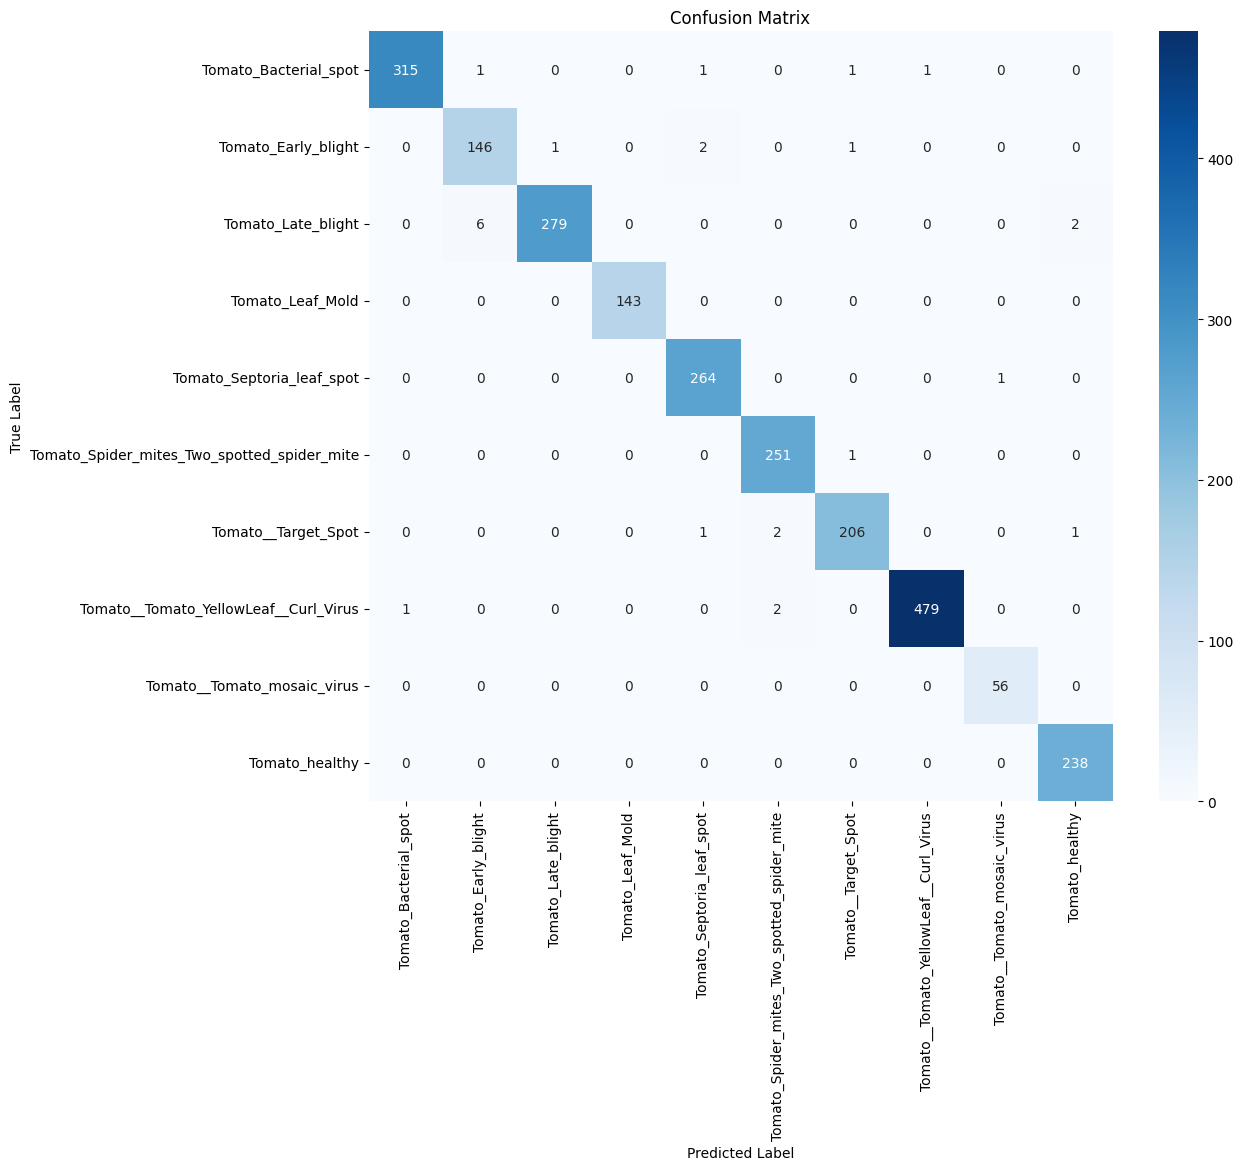

In [27]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[idx_to_class[i] for i in range(num_classes)],
    yticklabels=[idx_to_class[i] for i in range(num_classes)]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [28]:
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average AUC
all_auc = list(roc_auc.values())
macro_auc = np.mean(all_auc)

print("Per-class AUC:")
for i in range(num_classes):
    print(f"{idx_to_class[i]}: {roc_auc[i]:.4f}")

print(f"\nMacro Average AUC: {macro_auc:.4f}")

Per-class AUC:
Tomato_Bacterial_spot: 1.0000
Tomato_Early_blight: 0.9997
Tomato_Late_blight: 0.9991
Tomato_Leaf_Mold: 1.0000
Tomato_Septoria_leaf_spot: 1.0000
Tomato_Spider_mites_Two_spotted_spider_mite: 0.9999
Tomato__Target_Spot: 0.9999
Tomato__Tomato_YellowLeaf__Curl_Virus: 1.0000
Tomato__Tomato_mosaic_virus: 1.0000
Tomato_healthy: 1.0000

Macro Average AUC: 0.9998


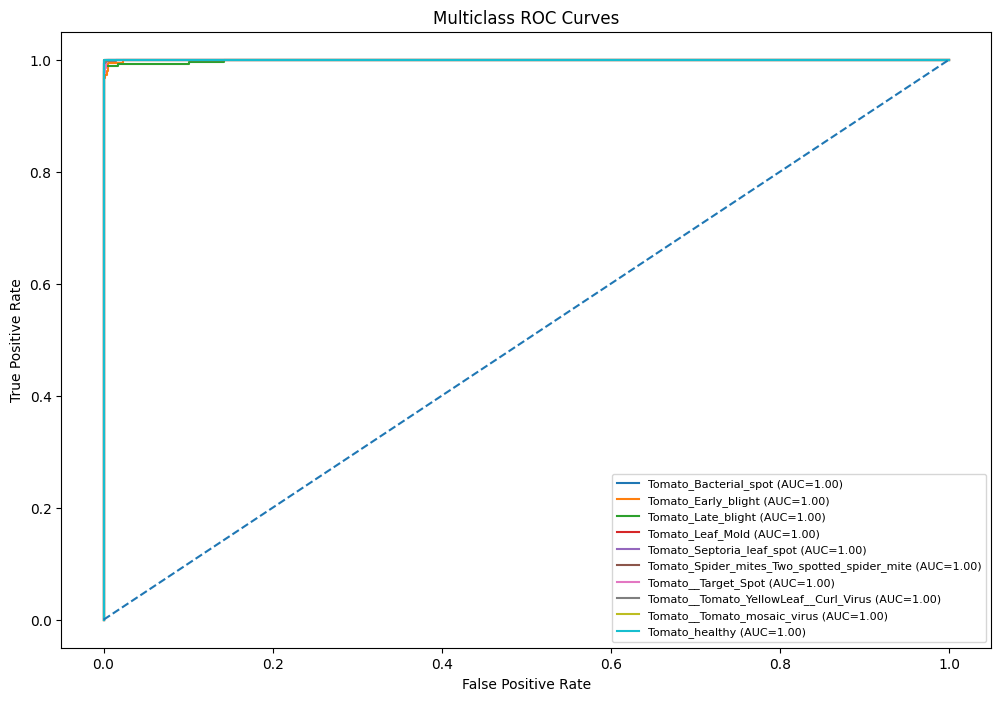

In [29]:
plt.figure(figsize=(12, 8))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"{idx_to_class[i]} (AUC={roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves")
plt.legend(loc="lower right", fontsize=8)
plt.show()

In [30]:
task4_results = pd.DataFrame({
    "Model": ["AttentionCNN + CBAM"],
    "Accuracy": [accuracy],
    "Precision (Macro)": [precision],
    "Recall (Macro)": [recall],
    "F1-score (Macro)": [f1],
    "AUC (Macro)": [macro_auc],
    "Training Time (sec)": [training_time],
    "Testing Time (sec)": [testing_time]
})

display(task4_results)

,Model,Accuracy,Precision (Macro),Recall (Macro),F1-score (Macro),AUC (Macro),Training Time (sec),Testing Time (sec)
0,AttentionCNN + CBAM,0.989592,0.987047,0.989991,0.988473,0.999839,2265.758002,15.583654


In [40]:
comparison_df = pd.DataFrame({
    "Model": [
        "ResNet50",
        "VGG16",
        "EfficientNetB0",
        "Custom CNN (Task 3)",
        "AttentionCNN + CBAM (Task 4)"
    ],
    "Accuracy": [
        0.9944,
        0.9547,
        0.9960,
        0.715654,
        0.989592   
    ],
    "Precision (Macro)": [
        0.9937,
        0.9501,
        0.9963,
        0.740954,
        0.987047
    ],
    "Recall (Macro)": [
        0.9935,
        0.9516,
        0.9953,
        0.697807,
        0.989991
    ],
    "F1-score (Macro)": [
        0.9936,
        0.9485,
        0.9958,
        0.662095,
        0.988473
    ],
    "AUC (Macro)": [
        1.0000,
        0.9992,
        1.0000,
        0.96961,
        0.999839
    ],
    "Training Time (sec)": [
        42.5 * 60,
        90 * 60,
        29 * 60,
        1297.607147,
        2172.702322
    ],
    "Testing Time (sec)": [
        17.22,
        28.70,
        9.29,
        11.278245,
        10.800865
    ]
})

display(comparison_df)

,Model,Accuracy,Precision (Macro),Recall (Macro),F1-score (Macro),AUC (Macro),Training Time (sec),Testing Time (sec)
0,ResNet50,0.994400,0.993700,0.993500,0.993600,1.000000,2550.000000,17.220000
1,VGG16,0.954700,0.950100,0.951600,0.948500,0.999200,5400.000000,28.700000
2,EfficientNetB0,0.996000,0.996300,0.995300,0.995800,1.000000,1740.000000,9.290000
3,Custom CNN (Task 3),0.715654,0.740954,0.697807,0.662095,0.969610,1297.607147,11.278245
4,AttentionCNN + CBAM (Task 4),0.989592,0.987047,0.989991,0.988473,0.999839,2172.702322,10.800865
